In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(67)

In [2]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        self.act           = torch.nn.Tanh()
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain(self.activation)
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [3]:
BATCH_SIZE = 32
EPOCHS  = 50

In [4]:
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 1000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 500)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

In [5]:
def f(x):
    return torch.sin(x)

def g(t):
    return torch.sin(t)

domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]

def get_initial(data):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = f(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)

    return u


def get_BC(data):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    t = data[:,1]

    # x = 0
    data_0 = data.clone()
    data_0[:,0] = domain[0][0]
    u_0 = g(t)

    # x = L
    data_L = data.clone()
    data_L[:,0] = domain[0][1]
    u_L = g(t)

    return data_0, data_L, u_0, u_L

def get_interior(data): # returns x (location)
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

get_BC(next(iter(train_dataloader)))

(tensor([[0.0000, 1.8711],
         [0.0000, 1.8945],
         [0.0000, 0.1875],
         [0.0000, 1.0586],
         [0.0000, 0.1152],
         [0.0000, 1.6016],
         [0.0000, 1.4922],
         [0.0000, 0.3066],
         [0.0000, 0.3926],
         [0.0000, 0.5273],
         [0.0000, 1.2090],
         [0.0000, 1.4688],
         [0.0000, 0.5352],
         [0.0000, 0.3184],
         [0.0000, 0.6328],
         [0.0000, 1.4258],
         [0.0000, 0.0000],
         [0.0000, 1.6523],
         [0.0000, 0.8125],
         [0.0000, 1.3672],
         [0.0000, 0.4531],
         [0.0000, 1.3340],
         [0.0000, 1.7148],
         [0.0000, 0.0664],
         [0.0000, 0.8906],
         [0.0000, 0.9551],
         [0.0000, 0.4395],
         [0.0000, 0.6094],
         [0.0000, 0.9043],
         [0.0000, 0.7598],
         [0.0000, 1.4297],
         [0.0000, 1.1719]]),
 tensor([[1.0000, 1.8711],
         [1.0000, 1.8945],
         [1.0000, 0.1875],
         [1.0000, 1.0586],
         [1.0000, 0.1152],

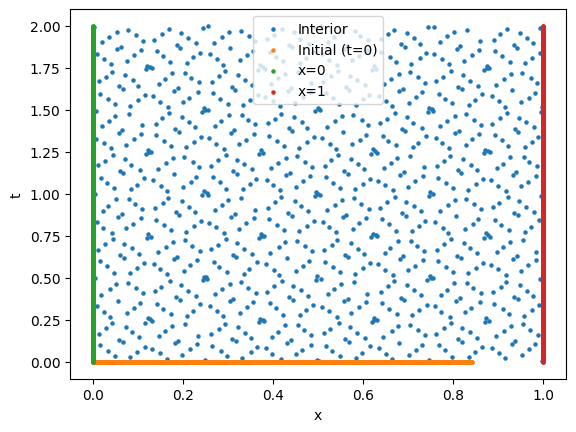

In [6]:
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data)
ic = get_initial(data)
bc_0, bc_L, u_0, u_L = get_BC(data)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(ic[:,0], ic[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [7]:
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 4, neurons = 20)

def get_interior_residual(u_model, points, alpha, epsilon):
    points.requires_grad = True

    u = u_model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph = True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    u_xx = torch.autograd.grad(u_x.sum(), points, create_graph=True)[0][:, 0]

    interior_residual = u_t + (alpha * u_x) - (epsilon * u_xx)

    return interior_residual.unsqueeze(1)

In [8]:
interior_data = get_interior(next(iter(train_dataloader)))
get_interior_residual(u_predictor_model, interior_data, 1, 1).shape

torch.Size([32, 1])

In [9]:
def get_IC_residue(u_model, points, f):

    u_0_data = points.clone().detach().requires_grad_(True) # u at t = 0

    u = u_model(u_0_data) 
    ic_1_residue = u - f(u_0_data[:, 0].unsqueeze(1))

    return ic_1_residue

IC_data = get_initial(next(iter(train_dataloader))) # u, u_t (exact at t = 0)
get_IC_residue(u_predictor_model, IC_data, f).shape


torch.Size([32, 1])

In [10]:
def get_BC_residue(u_model, points, g):
    return (u_model(points[0]) - g(points[2].unsqueeze(1))) + (u_model(points[1]) - g(points[3].unsqueeze(1)))


BC_data = get_BC(next(iter(train_dataloader))) 
get_BC_residue(u_predictor_model, BC_data, g).shape

torch.Size([32, 1])

In [11]:
def grad_norm(loss, models):
    if not isinstance(models, list):
        models = [models]

    params = []
    for m in models:
        params += list(m.parameters())

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        allow_unused=True
    )

    norm = 0.0
    for g in grads:
        if g is not None:
            norm += torch.sum(g**2)
    return torch.sqrt(norm)

In [ ]:
optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()),
    lr=1e-3
)

alpha = 0.1
epsilon = 10

epoch_loss_track = []
epoch_loss_track_test = []
residue_tracker = {}
grad_tracker = {
    "pde": [],
    "ic": [],
    "bc": []
}

for epoch in range(EPOCHS):
    lambda_pde = 1.0
    lambda_ic  = 1.0
    lambda_bc  = 1.0
    
    residue_tracker[epoch] = []
    
    epoch_loss = 0
    epoch_loss_test = 0

    epoch_loss_PDE = 0
    epoch_loss_IC = 0
    epoch_loss_BC = 0

    g_pde_epoch = 0
    g_ic_epoch = 0
    g_bc_epoch = 0

    for train_data in train_dataloader:
        u_predictor_model.train()


        optimizer.zero_grad()
        interior_data = get_interior(train_data) 
        IC_data       = get_initial(train_data) 
        BC_data       = get_BC(train_data)


        interior_residue  = get_interior_residual(u_predictor_model, interior_data, alpha, epsilon)
        IC_residue        = get_IC_residue(u_predictor_model, IC_data, f)
        BC_residue        = get_BC_residue(u_predictor_model, BC_data, g)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        models = [u_predictor_model]
        g_pde = grad_norm(loss_pde, models)
        g_ic  = grad_norm(loss_ic, models)
        g_bc  = grad_norm(loss_bc, models)

        g_pde_epoch += g_pde
        g_ic_epoch  += g_ic
        g_bc_epoch  += g_bc


        # total of iniduvidual residue
        epoch_loss_PDE += loss_pde
        epoch_loss_IC += loss_ic
        epoch_loss_BC += loss_bc

        # total
        
        loss = lambda_pde * loss_pde + lambda_ic * loss_ic + lambda_bc * loss_bc
        epoch_loss += loss
        loss.backward()
        optimizer.step()

        grad_tracker["pde"].append(g_pde.item())
        grad_tracker["ic"].append(g_ic.item())
        grad_tracker["bc"].append(g_bc.item())

    # grad_tracker["pde"].append((g_pde_epoch / len(train_dataloader)).item())
    # grad_tracker["ic"].append((g_ic_epoch / len(train_dataloader)).item())
    # grad_tracker["bc"].append((g_bc_epoch / len(train_dataloader)).item())

    residue_tracker[epoch].extend((epoch_loss_PDE.item()/len(train_dataloader), 
                                   epoch_loss_IC.item()/len(train_dataloader), 
                                   epoch_loss_BC.item()/len(train_dataloader)))

    for test_data in test_dataloader:
        
        u_predictor_model.eval()

        interior_data = get_interior(test_data) 
        IC_data       = get_initial(test_data) 
        BC_data       = get_BC(test_data)

        interior_residue = get_interior_residual(u_predictor_model, interior_data, alpha, epsilon)
        IC_residue       = get_IC_residue(u_predictor_model, IC_data, f)
        BC_residue       = get_BC_residue(u_predictor_model, BC_data, g)

        loss_pde = torch.mean(interior_residue**2)
        loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
        loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

        # total
        loss = loss_pde + loss_ic + loss_bc
        epoch_loss_test += loss
    
    epoch_loss = epoch_loss / len(train_dataloader)
    epoch_loss_track.append(epoch_loss.item())

    epoch_loss_test = epoch_loss_test / len(test_dataloader)
    epoch_loss_track_test.append(epoch_loss_test.item())


    if epoch % 10 == 0:
        print(f"EPOCH: {epoch} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")

EPOCH: 0 | train loss: 2.6534 | test loss: 0.8300
EPOCH: 10 | train loss: 0.1918 | test loss: 0.1151
EPOCH: 20 | train loss: 0.1669 | test loss: 0.0840
EPOCH: 30 | train loss: 0.1582 | test loss: 0.2284
EPOCH: 40 | train loss: 0.1727 | test loss: 0.1150


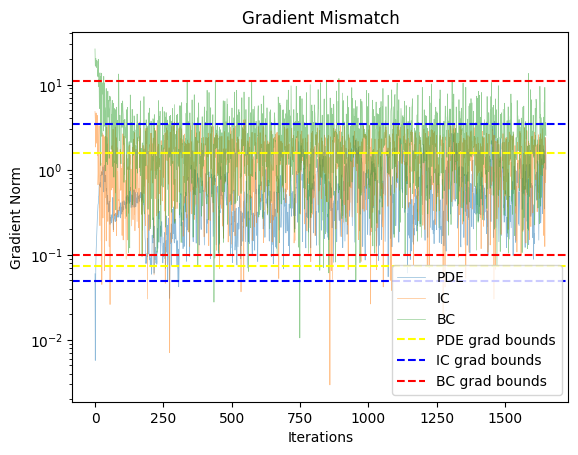

In [73]:
plt.plot(grad_tracker["pde"], label="PDE", alpha = 0.5, linewidth=0.5)
plt.plot(grad_tracker["ic"], label="IC", alpha = 0.5, linewidth=0.5)
plt.plot(grad_tracker["bc"], label="BC", alpha = 0.5, linewidth=0.5)

def bounds(tracker, window):
    pde_maxs = []
    pde_mins = []
    for i in range(len(tracker) // window):
        pde_maxs.append(max(tracker[i * window + i: (i + 1) * window]))
        pde_mins.append(min(tracker[i * window + i: (i + 1) * window]))
    return pde_maxs, pde_mins

pde_maxs, pde_mins = bounds(grad_tracker["pde"], 100)
ic_maxs, ic_mins = bounds(grad_tracker["ic"], 100)
bc_maxs, bc_mins = bounds(grad_tracker["bc"], 100)

pde_avg_max = sum(pde_maxs)/len(pde_maxs)
pde_avg_min = sum(pde_mins)/len(pde_mins)

ic_avg_max = sum(ic_maxs)/len(ic_maxs)
ic_avg_min = sum(ic_mins)/len(ic_mins)

bc_avg_max = sum(bc_maxs)/len(bc_maxs)
bc_avg_min = sum(bc_mins)/len(bc_mins)


plt.axhline(pde_avg_max, linestyle = "--", color = "yellow", label = "PDE grad bounds")
plt.axhline(pde_avg_min, linestyle = "--", color = "yellow")

plt.axhline(ic_avg_max, linestyle = "--", color = "blue", label = "IC grad bounds")
plt.axhline(ic_avg_min, linestyle = "--", color = "blue")

plt.axhline(bc_avg_max, linestyle = "--", color = "red", label = "BC grad bounds")
plt.axhline(bc_avg_min, linestyle = "--", color = "red")

plt.yscale("log")
plt.legend()
plt.title("Gradient Mismatch")
plt.xlabel("Iterations")
plt.ylabel("Gradient Norm")
plt.show()

In [77]:
print(pde_avg_max, ic_avg_max, ic_avg_max)

1.589924193918705 3.415293276309967 3.415293276309967


In [78]:
print(pde_avg_min, ic_avg_min, ic_avg_min)

0.07384188499418087 0.04963485604093876 0.04963485604093876


In [41]:
pde_maxs

[1.1260186433792114,
 0.47111308574676514,
 0.6206130385398865,
 0.5397979021072388,
 0.44956910610198975,
 0.36488303542137146,
 0.8081607222557068,
 1.0081133842468262,
 0.9424198865890503,
 1.0851444005966187,
 0.5481604933738708,
 0.9348739981651306,
 1.0053194761276245,
 1.1192511320114136,
 2.137211799621582,
 1.6211754083633423,
 1.446012258529663,
 0.8427426815032959,
 2.494077205657959,
 1.365258812904358,
 1.4373373985290527,
 1.803563117980957,
 1.643297553062439,
 1.563295841217041,
 1.0228197574615479,
 1.581868052482605,
 1.0893031358718872,
 1.291932225227356,
 1.4506328105926514,
 2.3081886768341064,
 1.188469648361206,
 1.1593081951141357,
 2.382880687713623]

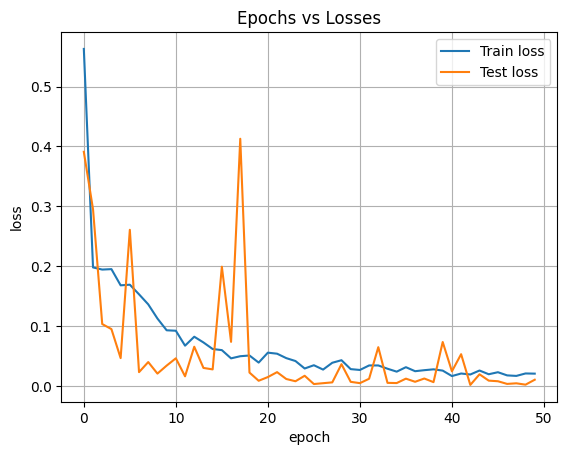

In [123]:
plt.plot(epoch_loss_track, label = "Train loss")
plt.plot(epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

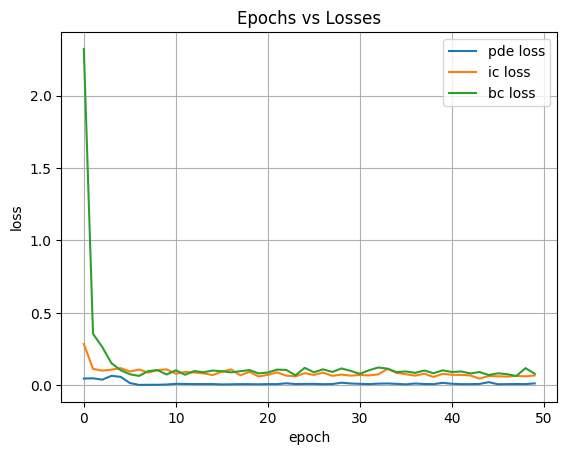

In [15]:
pde_loss = [v[0] for k, v in residue_tracker.items()]
ic_loss = [v[1] for k, v in residue_tracker.items()]
bc_loss = [v[2] for k, v in residue_tracker.items()]

plt.plot(pde_loss, label = "pde loss")
plt.plot(ic_loss, label = "ic loss")
plt.plot(bc_loss, label = "bc loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

# plt.yscale('log')

plt.show()

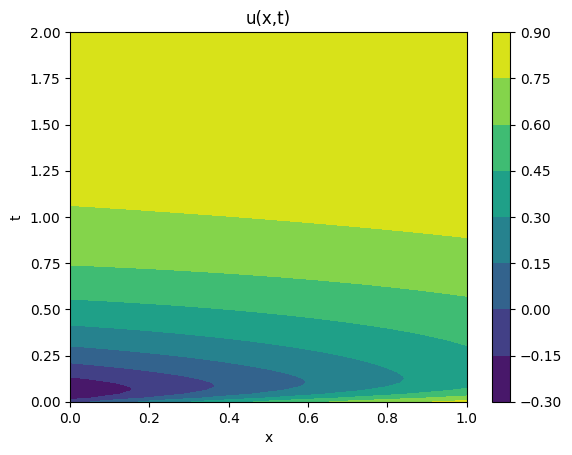

In [124]:
x_s = torch.linspace(domain[0][0], domain[0][1], 100)
t_s = torch.linspace(domain[1][0], domain[1][1], 100)

X, T = torch.meshgrid(x_s, t_s, indexing='ij')

points = torch.stack((X.flatten(), T.flatten()), dim=1)
points = points.clone().detach().requires_grad_(True)

u = u_predictor_model(points)

U = u.reshape(100, 100).detach().numpy()
plt.contourf(X.detach().numpy(), T.detach().numpy(), U)

plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("u(x,t)")
plt.show()
